# Evaluación 1

**Integrante 1:** Leandro flores

**Integrante 2:** Pablo Águila

**Integrante 3:** Pablo Saavedra

**Correo Electrónico integrante 1:** leandro.flores2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** pablo.aguila1901@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** pablo.saavedra2201@alumnos.ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.1

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
print(pd.__version__)
print(np.__version__)



2.2.2
2.0.2


#Carga de datos

In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-17 00:35:27--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv’

dataset_churn_dirty 100%[===================>]   2.64M  12.9MB/s    in 0.2s    

2026-04-17 00:35:27 (12.9 MB/s) - ‘dataset_churn_dirty.csv’ saved [2771759/2771759]



In [ ]:
data = pd.read_csv('dataset_churn_dirty.csv')
data.shape

(21000, 16)

# Revisión de nulos

In [ ]:
# Escriba su código acá

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferred_device       21000 non-null  object 
 15  ch

solo age, monthly_income,gender, payment_method tienes nulos, y no demasiados nice

# Revisión de atípicos

In [ ]:
# Escriba su código acá

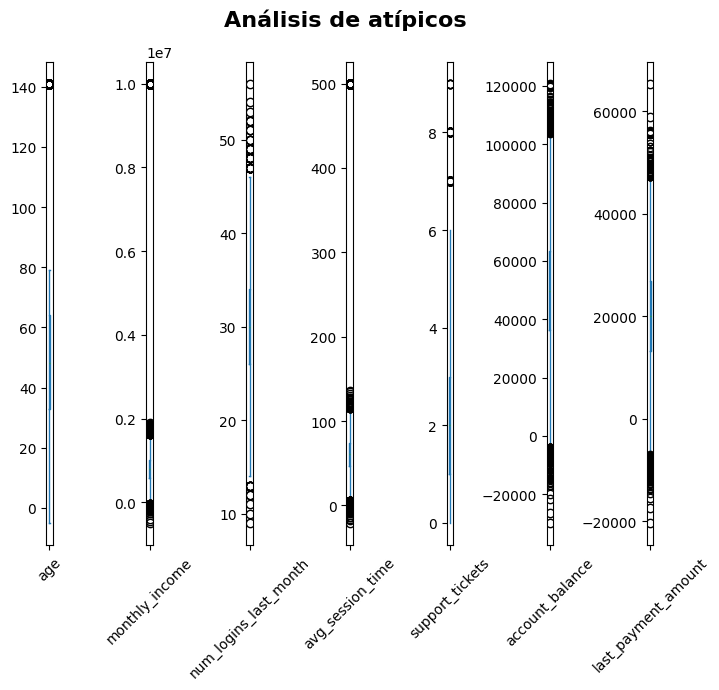

In [ ]:
revision_atipicos = ['age', 'monthly_income', 'num_logins_last_month',	'avg_session_time','support_tickets','account_balance','last_payment_amount',]
fig, axes = plt.subplots(1, 7, figsize=(20,40))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

hay atipicos, toca revisar si quitamos algunas de las opciones, los chunks no tienen atipicos, lo revise

#Revisión de inconsistencias

In [ ]:
# Escriba su código acá //lo veo en la reunion de mañana XD

In [ ]:
inconsistentes = data[( data["age"] <= 0 ) | (( data["monthly_income"] <= 0) | ( data["num_logins_last_month"] <= 0)) | (data ["avg_session_time"] <= 0) | (data ["support_tickets"] < 0)  | (data ["last_payment_amount"] <= 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
47,48,38.0,9.393170e+05,119,28,51.699977,3,71143.120322,-8638.523066,NaN,Premium,North,Debit Card,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
59,60,38.0,6.602348e+05,9,34,47.909770,2,71055.533036,-707.350603,Male,Enterprise,East,Debit Card,No,Tablet,0
65,66,38.0,-1.000000e+05,81,33,55.581316,1,15548.135456,17107.203175,Other,Enterprise,North,Transfer,No,Mobile,0
68,69,47.0,9.502943e+05,119,22,46.175998,0,33096.380063,-8091.022389,Male,Enterprise,North,Credit Card,No,Desktop,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20909,2256,-5.0,4.745605e+05,22,28,57.801877,1,55557.157569,31697.060773,Other,Enterprise,North,Debit Card,No,Mobile,0
20922,7271,31.0,7.601867e+05,17,44,67.498106,1,56370.726597,-1097.518661,Female,Premium,East,Transfer,Yes,Mobile,1
20926,7888,63.0,4.528124e+05,26,45,107.170665,3,41752.594619,-1682.760110,Other,Premium,West,PayPal,Yes,Desktop,1
20927,15710,74.0,-1.000000e+05,78,39,29.099820,0,61893.441053,33285.361859,Other,Enterprise,North,PayPal,No,Mobile,0


In [ ]:
import pandas as pd

!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-17 00:35:30--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv.1’

dataset_churn_dirty 100%[===================>]   2.64M  12.8MB/s    in 0.2s    

2026-04-17 00:35:30 (12.8 MB/s) - ‘dataset_churn_dirty.csv.1’ saved [2771759/2771759]



In [ ]:
data = pd.read_csv('dataset_churn_dirty.csv')
data.shape

(21000, 16)

ahora las cualitativas


In [ ]:
data.gender.unique()

array(['Other', nan, 'Female', 'Male'], dtype=object)

In [ ]:
data.subscription_type.unique()

array(['Enterprise', 'Basic', 'Premium'], dtype=object)

In [ ]:
data.region.unique()

array(['West', 'South', 'North', 'East'], dtype=object)

In [ ]:
data.payment_method.unique()

array([nan, 'Debit Card', 'Credit Card', 'PayPal', 'Transfer'],
      dtype=object)

In [ ]:
data.is_active.unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
data.preferred_device.unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

#Revisión de duplicados

In [ ]:
# Escriba su código acá

In [ ]:
data.duplicated().sum()

np.int64(1000)

In [ ]:
data[data.duplicated(keep=False)].sort_values(by='customer_id')

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20676,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19989,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


hay 2 mil duplicados, XD

estadisticas antes de la limpieza que vamos a hace

In [ ]:
data.drop(columns=['customer_id']).describe()

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,churn
count,19964.000000,1.996200e+04,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,48.763775,8.831296e+05,59.489476,29.950524,64.593725,1.999143,49991.270494,19994.073220,0.301619
std,20.781103,9.800619e+05,34.825396,5.484583,48.169755,1.411416,19927.866963,10035.594111,0.458972
min,-5.000000,-4.918861e+05,0.000000,9.000000,-20.873111,0.000000,-29809.544612,-20353.769010,0.000000
25%,33.000000,5.904548e+05,29.000000,26.000000,46.876785,1.000000,36437.872442,13248.528218,0.000000
50%,48.000000,7.989149e+05,59.000000,30.000000,60.323748,2.000000,49778.059812,19996.930030,0.000000
75%,64.000000,1.007102e+06,90.000000,34.000000,74.306634,3.000000,63433.887216,26828.259187,1.000000
max,141.000000,1.000000e+07,119.000000,56.000000,500.000000,9.000000,120775.517228,65425.194812,1.000000


In [ ]:
data.describe(include="object")

,gender,subscription_type,region,payment_method,is_active,preferred_device
count,19947,21000,21000,19953,21000,21000
unique,3,3,4,4,2,3
top,Other,Enterprise,East,PayPal,Yes,Mobile
freq,6763,7039,5316,5054,10523,7089


# Limpieza y transformación

In [ ]:
# Escriba su código acá

In [ ]:
data["age"] = data["age"].clip(0, 150)

# otros datos
cols_variables = ["monthly_income", "tenure_months", "num_logins_last_month","avg_session_time","support_tickets","last_payment_amount",]
data[cols_variables] = data[cols_variables].clip(lower=0)

# Guarda set de datos limpio y transformado

In [ ]:
# Escriba su código acá

In [ ]:
def feature_engineering(data: pd.DataFrame):
  """
  Realiza ingeniería de características

  Parámetros
  ----------
  data: DataFrame conteniendo los datos

  Retorno
  -------
  DataFrame con las nuevas características
  """
  data = data.copy()

  data["promedio"] = data[
        ["monthly_income"]
    ].mean(axis=1)

  data["diferencia"] = data["tenure_months"] - data["num_logins_last_month"]

  return data

In [ ]:
data_fe = feature_engineering(data.copy())

In [ ]:
data_fe["se queda"] = ((data_fe["churn"] == 1) & (data_fe['is_active'] == "Yes")).astype(int)

In [ ]:
data_corr = pd.get_dummies(
    data_fe,
    columns=["gender", "subscription_type", "region", "payment_method", "is_active", "preferred_device"],
    drop_first=True
)

In [ ]:
target = "se queda"
correlaciones = data_corr.drop(columns=["customer_id"]).corr()[target].round(4)
correlaciones

,se queda
age,-0.0032
monthly_income,-0.0038
tenure_months,-0.0028
num_logins_last_month,-0.0016
avg_session_time,-0.0057
support_tickets,-0.0013
account_balance,-0.0019
last_payment_amount,-0.0017
churn,0.6426
promedio,-0.0038


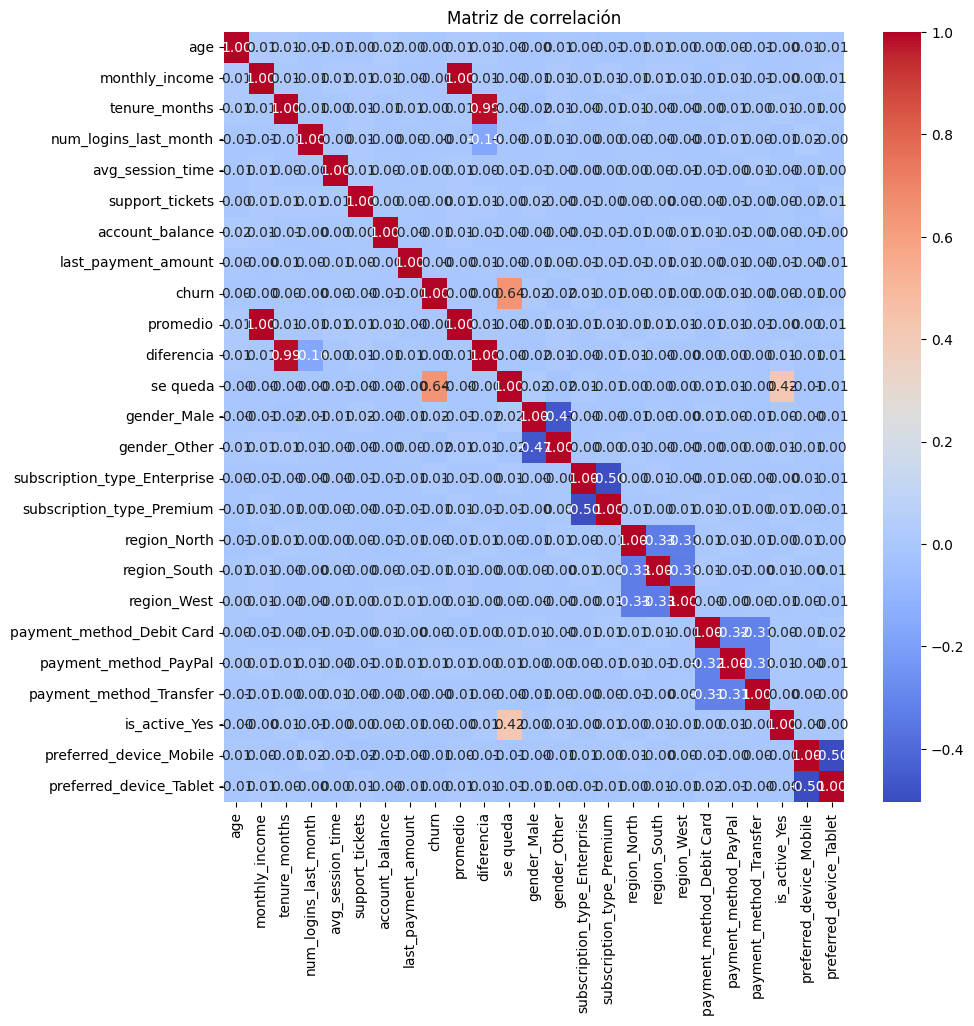

In [ ]:
correlaciones = data_corr.drop(columns=["customer_id"]).corr().round(4)
plt.figure(figsize=(10, 10))
sb.heatmap(correlaciones, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [ ]:
def eliminar_duplicados(X : pd.DataFrame):
  """
  Tratamiento de duplicados

  Parámetros
  ----------

  X: set de datos

  Retorno
  -------
  Nuevo set de datos SIN los duplicados

  """
  return X.drop_duplicates()

In [ ]:
X = data_fe.drop(columns=["se queda", "customer_id"])
y = data_fe["se queda"]

In [ ]:
numeric_features = ['monthly_income', 'tenure_months', 'num_logins_last_month','avg_session_time','support_tickets','last_payment_amount']
categorical_features = ["gender","subscription_type","region","payment_method","is_active","preferred_device"]

In [ ]:
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean")),
        ("escalado", StandardScaler())
    ]
)

In [ ]:
pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

In [ ]:
pipeline_limpieza_transformacion = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados)),
        ("feature_engineering", FunctionTransformer(feature_engineering)),
        ("preprocesamiento", preprocesador)
    ]
)

In [ ]:
X_clean = pipeline_limpieza_transformacion.fit_transform(X)

In [ ]:
data_clean = pd.DataFrame(
    X_clean,
    columns=pipeline_limpieza_transformacion.named_steps["preprocesamiento"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat__", "")
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

In [ ]:
data_clean.head()

,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,last_payment_amount,gender_Female,gender_Male,gender_Other,subscription_type_Basic,...,region_West,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_No,is_active_Yes,preferred_device_Desktop,preferred_device_Mobile,preferred_device_Tablet
0,0.000000,0.478751,1.819776,-1.627287,-1.462108,1.794273,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.873115,-0.395436,-0.579494,-0.534592,0.753319,0.669010,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.407393,0.682728,-1.379250,-0.404769,-0.723633,-0.504737,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.010693,-0.424575,-1.379250,-0.291530,-0.723633,1.794273,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-1.269265,1.119822,-0.179615,0.383539,0.753319,-0.579659,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
data_clean.shape

(20000, 25)

In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   monthly_income                20000 non-null  float64
 1   tenure_months                 20000 non-null  float64
 2   num_logins_last_month         20000 non-null  float64
 3   avg_session_time              20000 non-null  float64
 4   support_tickets               20000 non-null  float64
 5   last_payment_amount           20000 non-null  float64
 6   gender_Female                 20000 non-null  float64
 7   gender_Male                   20000 non-null  float64
 8   gender_Other                  20000 non-null  float64
 9   subscription_type_Basic       20000 non-null  float64
 10  subscription_type_Enterprise  20000 non-null  float64
 11  subscription_type_Premium     20000 non-null  float64
 12  region_East                   20000 non-null  float64
 13  r

In [ ]:
data_clean.describe()

,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,last_payment_amount,gender_Female,gender_Male,gender_Other,subscription_type_Basic,...,region_West,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_No,is_active_Yes,preferred_device_Desktop,preferred_device_Mobile,preferred_device_Tablet
count,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000,20000.000000,20000.000000
mean,-1.627143e-16,2.557954e-17,-1.211475e-16,-2.945200e-16,4.973799e-17,1.051603e-16,0.314250,0.313900,0.371850,0.334750,...,0.252700,0.233650,0.239050,0.289450,0.237850,0.49855,0.50145,0.328950,0.336850,0.334200
std,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,0.464228,0.464088,0.483311,0.471915,...,0.434571,0.423163,0.426514,0.453518,0.425777,0.50001,0.50001,0.469844,0.472645,0.471722
min,-1.888753e+00,-1.561018e+00,-1.779129e+00,-1.777220e+00,-1.462108e+00,-1.809170e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
25%,-6.962278e-01,-8.908083e-01,-7.794328e-01,-7.362518e-01,-7.236325e-01,-7.377835e-01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
50%,0.000000e+00,-1.662121e-02,2.032382e-02,-1.408862e-02,1.484337e-02,-1.177889e-03,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.00000,0.000000,0.000000,0.000000
75%,7.013011e-01,8.867054e-01,8.200805e-01,7.307914e-01,7.533193e-01,7.461054e-01,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,1.00000,1.00000,1.000000,1.000000,1.000000
max,1.873115e+00,1.586055e+00,1.819776e+00,1.851309e+00,2.230271e+00,1.794273e+00,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000,1.000000


Guardamos el DataFrame procesado `data_clean` en un archivo.

In [ ]:
data_clean.to_csv('dataset_churn_clean.csv', index=False)

from google.colab import files
files.download('dataset_churn_clean.csv')

print("Archivo 'dataset_churn_clean.csv' exportado exitosamente.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivo 'dataset_churn_clean.csv' exportado exitosamente.
